In [1]:

# Cell 1 — Install dependencies and clone repositories

!pip install --upgrade pip
!pip install torch torchinfo tqdm numpy scikit-learn matplotlib pandas toml

!rm -rf /content/KAN-AD
!rm -rf /content/datasets

!git clone https://github.com/CSTCloudOps/KAN-AD.git /content/KAN-AD
!git clone https://github.com/CSTCloudOps/datasets.git /content/datasets

!rm -rf /content/KAN-AD/datasets
!mv /content/datasets /content/KAN-AD/datasets

%cd /content/KAN-AD

Cloning into '/content/KAN-AD'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 61.77 KiB | 5.15 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Cloning into '/content/datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 22.52 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
/content/KAN-AD


In [2]:

# Cell 2 — Install EasyTSAD, fix import syntax issue, and configure paths

!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git
!sed -i 's/TSData,*/TSData/g' /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py || true
!grep -n "TSData" /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py | head -n 20

import os
import sys
import glob

REPO_ROOT = "/content/KAN-AD"
DATA_ROOT = "/content/KAN-AD/datasets"

sys.path.insert(0, REPO_ROOT)

candidates = glob.glob("/content/KAN-AD/**/kanad/kanad.py", recursive=True)
print("Found KAN-AD candidates:", candidates)
assert candidates, "Could not find kanad/kanad.py inside the cloned KAN-AD repo."

KANAD_PY = sorted(candidates, key=len)[0]
KANAD_PKG_DIR = os.path.dirname(KANAD_PY)
KANAD_ROOT_DIR = os.path.dirname(KANAD_PKG_DIR)

sys.path.insert(0, KANAD_ROOT_DIR)

print("KANAD_PKG_DIR =", KANAD_PKG_DIR)
print("KANAD_ROOT_DIR =", KANAD_ROOT_DIR)
print("sys.path[:4] =", sys.path[:4])

  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-g7l7twb1
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-g7l7twb1
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit 10f5e7a4b27f4a326961bb8a77176aac7f6d7cc1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
1:from .TSData import TSData
2:from .MTSData import MTSData
Found KAN-AD candidates: ['/content/KAN-AD/kanad/kanad.py']
KANAD_PKG_DIR = /content/KAN-AD/kanad
KANAD_ROOT_DIR = /content/KAN-AD
sys.path[:4] = ['/content/KAN-AD', '/content/KAN-AD', '/content', '/env/python']


In [3]:

# Cell 3 — Imports and sanity check

import json
import math
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import Dataset, DataLoader

from EasyTSAD.Controller import TSADController
from EasyTSAD.DataFactory import TSData
from EasyTSAD.Methods import BaseMethod
from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

from kanad import KANAD
from kanad.kanad import KANADModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("KANAD imported:", KANAD)
print("KANADModel imported:", KANADModel)
print("TSADController imported:", TSADController)

Device: cuda
KANAD imported: <class 'kanad.kanad.KANAD'>
KANADModel imported: <class 'kanad.kanad.KANADModel'>
TSADController imported: <class 'EasyTSAD.Controller.TSADController.TSADController'>


In [4]:
# Cell 4 — Define the Fourier-based KAN-AD backbone helpers + sensor attention

class PeriodicIndexBasisLayer(nn.Module):
    """
    Index-based periodic basis retained from the KAN-AD family:
        sin(2*pi*n*i/T), cos(2*pi*n*i/T)
    """

    def __init__(self, order: int, window: int):
        super().__init__()
        self.order = int(order)
        self.window = int(window)
        idx = torch.arange(self.window, dtype=torch.float32)
        self.register_buffer("idx", idx)

    def forward(self, x):
        B, W = x.shape
        feats = []
        t = self.idx.to(x.device)
        for n in range(1, self.order + 1):
            feats.append(torch.sin(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
            feats.append(torch.cos(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
        return torch.cat(feats, dim=1) if feats else torch.empty(B, 0, W, device=x.device)


class FourierBasisLayer(nn.Module):
    """
    Fourier family replacing RBF:
        cos(k * x)
    """

    def __init__(self, order: int):
        super().__init__()
        self.order = int(order)

    def forward(self, x):
        x = x.unsqueeze(1)
        feats = [torch.cos((i + 1) * x) for i in range(self.order)]
        return torch.cat(feats, dim=1) if feats else torch.empty_like(x)


class FastKANADModel(nn.Module):
    """
    Fourier-based KAN-AD backbone (RBF replaced with Fourier).

    Mapping channels:
      - Fourier basis channels
      - periodic index basis channels
      - raw input channel
    """

    def __init__(
        self,
        window: int,
        order: int = 2,
    ):
        super().__init__()

        self.window = int(window)
        self.order = int(order)

        # Fourier replaces RBF
        self.family_layer = FourierBasisLayer(order=self.order)
        self.family_out_channels = self.order

        self.periodic_layer = PeriodicIndexBasisLayer(order=self.order, window=self.window)
        self.periodic_out_channels = 2 * self.order

        self.channels = self.family_out_channels + self.periodic_out_channels + 1

        self.init_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.inner_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.out_conv = nn.Conv1d(self.channels, 1, kernel_size=1, bias=False)
        self.final_conv = nn.Conv1d(1, 1, kernel_size=self.window, stride=1, padding=0, bias=True)

        self.bn1 = nn.BatchNorm1d(self.channels)
        self.bn2 = nn.BatchNorm1d(self.channels)
        self.bn3 = nn.BatchNorm1d(1)
        self.act = nn.GELU()

    def forward_feature(self, x: torch.Tensor):
        raw = x.unsqueeze(1)

        # 🔥 Fourier instead of RBF
        family = self.family_layer(x)

        periodic = self.periodic_layer(x)

        ff = torch.cat([family, periodic, raw], dim=1)
        res0 = raw
        res1 = ff

        ff = self.act(self.bn1(self.init_conv(ff)))
        ff = self.act(self.bn2(self.inner_conv(ff) + res1))
        ff = self.act(self.bn3(self.out_conv(ff) + res0))
        return ff

    def forward_head(self, ff: torch.Tensor):
        return self.final_conv(ff).squeeze(1)

    def forward(self, x: torch.Tensor):
        ff = self.forward_feature(x)
        return self.forward_head(ff)


# ⚠️ DO NOT CHANGE attention (keep exactly same)
class SensorSelfAttention(nn.Module):
    def __init__(self, n_features: int, d_model: int = 16, n_heads: int = 2, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_features = int(n_features)
        self.embed = nn.Linear(1, d_model)
        self.mha = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, F = x.shape

        xt = x.reshape(B * T, F, 1)
        z = self.embed(xt)

        if return_attn:
            z_attn, attn = self.mha(z, z, z, need_weights=True, average_attn_weights=True)
            attn_avg = attn.mean(dim=0)
        else:
            z_attn, _ = self.mha(z, z, z, need_weights=False)
            attn_avg = None

        y = self.out(z_attn).squeeze(-1)
        x_mix = y.reshape(B, T, F)
        return x_mix, attn_avg


print("Fourier FastKANADModel + SensorSelfAttention ready.")

Fourier FastKANADModel + SensorSelfAttention ready.


In [5]:
# Cell 5 — Build MSL holdout dataset + save calibration arrays outside EasyTSAD tree

import os
import shutil
import numpy as np

ROOT_DIR = "/content/KAN-AD"
DATA_ROOT = os.path.join(ROOT_DIR, "datasets", "MTS")

ORIG_DATASET = "MSL"
CUSTOM_DATASET = "MSL_HybridHoldout"

orig_curve_dir = os.path.join(DATA_ROOT, ORIG_DATASET, "AllInOne")
custom_dataset_dir = os.path.join(DATA_ROOT, CUSTOM_DATASET)
custom_curve_dir = os.path.join(custom_dataset_dir, "AllInOne")

print("Original MSL curve dir:", orig_curve_dir)

train = np.load(os.path.join(orig_curve_dir, "train.npy"))
test = np.load(os.path.join(orig_curve_dir, "test.npy"))
test_label = np.load(os.path.join(orig_curve_dir, "test_label.npy"))
train_label = np.zeros(len(train), dtype=np.int64)

print("train shape:", train.shape)
print("test shape :", test.shape)
print("test_label positives:", int(test_label.sum()))

test_len = len(test)
default_calib_end = int(0.20 * test_len)

positive_idx = np.where(test_label > 0)[0]
if len(positive_idx) == 0:
    raise ValueError("MSL test labels contain no anomalies; cannot build calibration split.")

last_pos = int(positive_idx[min(len(positive_idx) - 1, max(0, int(0.10 * len(positive_idx))))])
calib_end = max(default_calib_end, last_pos + 1)
calib_end = min(calib_end, test_len - 1)

calib_arr = test[:calib_end].copy()
calib_label = test_label[:calib_end].copy()

final_test = test[calib_end:].copy()
final_test_label = test_label[calib_end:].copy()

print("\nChosen calibration end index:", calib_end)
print("Calibration shape:", calib_arr.shape, " positives:", int(calib_label.sum()))
print("Final test shape :", final_test.shape, " positives:", int(final_test_label.sum()))

if calib_label.sum() == 0:
    raise ValueError("Calibration split still has no anomalies. Increase calibration size.")

if os.path.exists(custom_dataset_dir):
    shutil.rmtree(custom_dataset_dir)

os.makedirs(custom_curve_dir, exist_ok=True)

np.save(os.path.join(custom_curve_dir, "train.npy"), train)
np.save(os.path.join(custom_curve_dir, "train_label.npy"), train_label)
np.save(os.path.join(custom_curve_dir, "test.npy"), final_test)
np.save(os.path.join(custom_curve_dir, "test_label.npy"), final_test_label)

# IMPORTANT: copy metadata files required by EasyTSAD
for extra_name in ["info.json", "meta.json"]:
    src = os.path.join(orig_curve_dir, extra_name)
    dst = os.path.join(custom_curve_dir, extra_name)
    if os.path.exists(src):
        shutil.copy2(src, dst)

RUNTIME_DIR = os.path.join(ROOT_DIR, "kanad_runtime")
os.makedirs(RUNTIME_DIR, exist_ok=True)

CALIB_DIR = os.path.join(RUNTIME_DIR, f"{CUSTOM_DATASET}_calibration")
if os.path.exists(CALIB_DIR):
    shutil.rmtree(CALIB_DIR)
os.makedirs(CALIB_DIR, exist_ok=True)

np.save(os.path.join(CALIB_DIR, "calib.npy"), calib_arr)
np.save(os.path.join(CALIB_DIR, "calib_label.npy"), calib_label)

print("\nCreated dataset at:", custom_curve_dir)
print("Saved files:", sorted(os.listdir(custom_curve_dir)))
print("\nCalibration dir:", CALIB_DIR)
print("Calibration files:", sorted(os.listdir(CALIB_DIR)))

assert os.path.exists(os.path.join(custom_curve_dir, "train.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test_label.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "info.json"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib_label.npy"))

print("\nCell 5 completed successfully.")

Original MSL curve dir: /content/KAN-AD/datasets/MTS/MSL/AllInOne
train shape: (58317, 55)
test shape : (73729, 55)
test_label positives: 7766

Chosen calibration end index: 14745
Calibration shape: (14745, 55)  positives: 2034
Final test shape : (58984, 55)  positives: 5732

Created dataset at: /content/KAN-AD/datasets/MTS/MSL_HybridHoldout/AllInOne
Saved files: ['info.json', 'test.npy', 'test_label.npy', 'train.npy', 'train_label.npy']

Calibration dir: /content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration
Calibration files: ['calib.npy', 'calib_label.npy']

Cell 5 completed successfully.


In [6]:

# Cell 6 — Utility functions: segmentation, calibration F1 search, normalization, plotting

def contiguous_segments(binary_labels: np.ndarray):
    y = np.asarray(binary_labels).astype(int)
    segs = []
    start = None
    for i, v in enumerate(y):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            segs.append((start, i - 1))
            start = None
    if start is not None:
        segs.append((start, len(y) - 1))
    return segs


def segment_overlap(a, b):
    return not (a[1] < b[0] or b[1] < a[0])


def event_f1_from_binary(pred_binary: np.ndarray, true_binary: np.ndarray):
    gt_segs = contiguous_segments(true_binary)
    pr_segs = contiguous_segments(pred_binary)

    if len(gt_segs) == 0 and len(pr_segs) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_segs) == 0:
        return 0.0, 0.0, 0.0
    if len(pr_segs) == 0:
        return 0.0, 0.0, 0.0

    used_pr = set()
    tp = 0
    for gt in gt_segs:
        for j, pr in enumerate(pr_segs):
            if j in used_pr:
                continue
            if segment_overlap(gt, pr):
                tp += 1
                used_pr.add(j)
                break

    precision = tp / max(len(pr_segs), 1)
    recall = tp / max(len(gt_segs), 1)
    f1 = 0.0 if (precision + recall == 0) else 2 * precision * recall / (precision + recall)
    return f1, precision, recall


def best_event_f1_threshold(scores: np.ndarray, labels: np.ndarray, n_grid: int = 200):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(int)

    if labels.sum() == 0:
        return 0.0, float(np.max(scores)), 0.0, 0.0

    lo = float(np.min(scores))
    hi = float(np.max(scores))

    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError("Non-finite scores encountered during threshold search.")

    if hi <= lo:
        pred = (scores > lo).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        return f1, lo, p, r

    thresholds = np.linspace(lo, hi, n_grid)
    best = (-1.0, lo, 0.0, 0.0)

    for thr in thresholds:
        pred = (scores > thr).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        if f1 > best[0]:
            best = (f1, float(thr), float(p), float(r))

    return best


def sigmoid_np(x):
    x = np.clip(x, -8.0, 8.0)
    return 1.0 / (1.0 + np.exp(-x))


def zscore_sigmoid(x, mu, std, eps=1e-8):
    z = (x - mu) / (std + eps)
    return sigmoid_np(z)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_overlay(scores, labels, title, max_points=4000):
    n = min(len(scores), max_points)
    x = np.arange(n)
    plt.figure(figsize=(14, 4))
    plt.plot(x, scores[:n], label="score")
    if labels is not None and n > 0:
        ymax = max(1e-6, float(np.max(scores[:n])))
        plt.fill_between(x, 0, ymax, where=labels[:n].astype(bool), alpha=0.2, step="pre", label="anomaly")
    plt.title(title)
    plt.legend()
    plt.show()

In [7]:

# Cell 7 — Window datasets for train/valid/test and calibration

class MTSWindowDataset(Dataset):
    def __init__(self, tsData, phase, window_size):
        self.window_size = int(window_size)

        if phase == "train":
            self.data = np.asarray(tsData.train)
        elif phase == "valid":
            self.data = np.asarray(tsData.valid)
        elif phase == "test":
            self.data = np.asarray(tsData.test)
        else:
            raise ValueError("phase must be train / valid / test")

        assert self.data.ndim == 2, f"Expected 2D MTS array, got {self.data.shape}"
        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class ArrayWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray, window_size: int):
        self.data = np.asarray(data)
        self.labels = np.asarray(labels).astype(int)
        self.window_size = int(window_size)

        assert self.data.ndim == 2, f"Expected 2D array, got {self.data.shape}"
        assert len(self.data) == len(self.labels), "Data/label length mismatch"

        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        label = self.labels[idx + self.window_size]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

print("Datasets ready.")

Datasets ready.


In [8]:
# Cell 8 — Define the attention-enhanced hybrid model with alpha tuning on calibration data

class Attn_FastKANAD_SVDD_AlphaTuned_Holdout(BaseMethod):
    def __init__(self, params: dict) -> None:
        super().__init__()

        self.__anomaly_score = None

        self.batch_size = int(params["batch_size"])
        self.window = int(params["window"])
        self.order = int(params["order"])
        self.epochs = int(params["epochs"])
        self.lr = float(params["lr"])

        self.lambda_svdd = float(params.get("lambda_svdd", 0.1))
        self.emb_dim = int(params.get("emb_dim", 64))
        self.patience = int(params.get("patience", 6))

        self.alpha_grid = params.get("alpha_grid", [round(x, 2) for x in np.linspace(0, 1, 11)])
        self.calib_data_path = params["calib_data_path"]
        self.calib_label_path = params["calib_label_path"]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # MSL has 55 features
        self.n_features = int(params.get("n_features", 55))
        self.attn_d_model = int(params.get("attn_d_model", 16))
        self.attn_heads = int(params.get("attn_heads", 2))
        self.attn_dropout = float(params.get("attn_dropout", 0.0))

        self.model = FastKANADModel(
            window=self.window,
            order=self.order,
        ).to(self.device)

        self.sensor_attn = SensorSelfAttention(
            n_features=self.n_features,
            d_model=self.attn_d_model,
            n_heads=self.attn_heads,
            dropout=self.attn_dropout,
        ).to(self.device)

        self.embed_head = nn.Sequential(
            nn.Linear(self.window, 128),
            nn.GELU(),
            nn.Linear(128, self.emb_dim),
        ).to(self.device)

        self.optimizer = optim.Adam(
            list(self.model.parameters()) +
            list(self.sensor_attn.parameters()) +
            list(self.embed_head.parameters()),
            lr=self.lr
        )
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=5, gamma=0.75)
        self.mse_loss = nn.MSELoss()

        self.center = None
        self.last_attn_matrix = None

        self.pred_mu = None
        self.pred_std = None
        self.svdd_mu = None
        self.svdd_std = None

        self.alpha = 0.5
        self.best_calib_event_f1 = None
        self.best_calib_threshold = None
        self.calib_tuning_table = None

        self.best_state = None

    def _compute_embedding(self, ff):
        feat = ff.squeeze(1)
        return self.embed_head(feat)

    def _mix_sensors(self, x, return_attn: bool = False):
        x_mix, attn_avg = self.sensor_attn(x, return_attn=return_attn)
        if attn_avg is not None:
            self.last_attn_matrix = attn_avg.detach().cpu()
        return x_mix

    def _forward_batch(self, x, target):
        B, W, F = x.shape

        x_mix = self._mix_sensors(x, return_attn=False)
        x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)
        t_1d = target.reshape(B * F, 1)

        ff = self.model.forward_feature(x_1d)
        out = self.model.forward_head(ff).reshape(B * F, 1)

        pred_loss = self.mse_loss(out, t_1d)
        pred_err = (out - t_1d).abs().reshape(B, F).max(dim=1).values

        z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
        svdd_dist = ((z - self.center) ** 2).sum(dim=1)
        svdd_loss = svdd_dist.mean()

        return pred_err, svdd_dist, pred_loss, svdd_loss

    def _compute_center(self, train_loader):
        zs = []
        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            for x, y in tqdm.tqdm(train_loader, desc="Compute SVDD center"):
                x = x.to(self.device)

                B, W, F = x.shape
                x_mix = self._mix_sensors(x, return_attn=False)
                x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)

                ff = self.model.forward_feature(x_1d)
                z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
                zs.append(z.detach().cpu())

        Z = torch.cat(zs, dim=0)
        c = Z.mean(dim=0).to(self.device)
        c[(c.abs() < 1e-6)] = 1e-6
        self.center = c

    def _collect_components_from_loader(self, loader, has_labels=False):
        pred_all = []
        svdd_all = []
        label_all = []

        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            if has_labels:
                iterator = loader
            else:
                iterator = ((x, y, None) for x, y in loader)

            for x, y, lab in iterator:
                x = x.to(self.device)
                y = y.to(self.device)

                pred_err, svdd_dist, _, _ = self._forward_batch(x, y)

                pred_all.append(pred_err.detach().cpu().numpy())
                svdd_all.append(svdd_dist.detach().cpu().numpy())

                if lab is not None:
                    label_all.append(lab.detach().cpu().numpy())

        pred_all = np.concatenate(pred_all) if pred_all else np.array([], dtype=float)
        svdd_all = np.concatenate(svdd_all) if svdd_all else np.array([], dtype=float)

        if has_labels:
            label_all = np.concatenate(label_all) if label_all else np.array([], dtype=int)
            return pred_all, svdd_all, label_all

        return pred_all, svdd_all

    def _fit_normalization_stats(self, train_loader):
        pred_train, svdd_train = self._collect_components_from_loader(train_loader, has_labels=False)

        self.pred_mu = float(pred_train.mean())
        self.pred_std = float(pred_train.std() + 1e-8)
        self.svdd_mu = float(svdd_train.mean())
        self.svdd_std = float(svdd_train.std() + 1e-8)

        print("\nNormalization statistics (train only)")
        print(f"pred_mu={self.pred_mu:.6f}, pred_std={self.pred_std:.6f}")
        print(f"svdd_mu={self.svdd_mu:.6f}, svdd_std={self.svdd_std:.6f}")

    def _tune_alpha_on_calibration(self):
        calib_data = np.load(self.calib_data_path)
        calib_label = np.load(self.calib_label_path)

        calib_loader = DataLoader(
            ArrayWindowDataset(calib_data, calib_label, self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_c, svdd_c, labels_c = self._collect_components_from_loader(calib_loader, has_labels=True)

        pred_c_n = zscore_sigmoid(pred_c, self.pred_mu, self.pred_std)
        svdd_c_n = zscore_sigmoid(svdd_c, self.svdd_mu, self.svdd_std)

        print("\nAlpha tuning on calibration split")
        best = (-1.0, None, None, None, None)
        rows = []

        for alpha in self.alpha_grid:
            fused = alpha * pred_c_n + (1.0 - alpha) * svdd_c_n
            best_f1, best_thr, best_p, best_r = best_event_f1_threshold(fused, labels_c, n_grid=200)

            rows.append({
                "alpha": float(alpha),
                "event_f1": float(best_f1),
                "precision": float(best_p),
                "recall": float(best_r),
                "threshold": float(best_thr),
            })

            print(f"alpha={alpha:.2f} | calib_event_f1={best_f1:.6f} | threshold={best_thr:.6f}")

            if best_f1 > best[0]:
                best = (best_f1, alpha, best_thr, labels_c, fused)

        self.best_calib_event_f1 = float(best[0])
        self.alpha = float(best[1])
        self.best_calib_threshold = float(best[2])
        self.calib_tuning_table = pd.DataFrame(rows)

        print(f"\nSelected alpha={self.alpha:.2f} with calib_event_f1={self.best_calib_event_f1:.6f}")
        print(f"Selected calibration threshold={self.best_calib_threshold:.6f}")

        show_overlay(best[4], best[3], f"Calibration fused score overlay (best alpha={self.alpha:.2f})")

    def train_valid_phase(self, tsTrain: TSData):
        train_loader = DataLoader(
            MTSWindowDataset(tsTrain, "train", self.window),
            batch_size=self.batch_size,
            shuffle=True
        )
        valid_loader = DataLoader(
            MTSWindowDataset(tsTrain, "valid", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        self._compute_center(train_loader)

        best_valid = float("inf")
        patience_counter = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            self.sensor_attn.train()
            self.embed_head.train()

            train_losses = []
            train_pred_losses = []
            train_svdd_losses = []

            for x, y in tqdm.tqdm(train_loader, desc=f"Train {epoch}"):
                x = x.to(self.device)
                y = y.to(self.device)

                self.optimizer.zero_grad(set_to_none=True)

                pred_err, svdd_dist, pred_loss, svdd_loss = self._forward_batch(x, y)
                total_loss = pred_loss + self.lambda_svdd * svdd_loss

                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.model.parameters()) +
                    list(self.sensor_attn.parameters()) +
                    list(self.embed_head.parameters()),
                    max_norm=5.0
                )
                self.optimizer.step()

                train_losses.append(float(total_loss.item()))
                train_pred_losses.append(float(pred_loss.item()))
                train_svdd_losses.append(float(svdd_loss.item()))

            self.model.eval()
            self.sensor_attn.eval()
            self.embed_head.eval()

            valid_losses = []
            with torch.no_grad():
                for x, y in tqdm.tqdm(valid_loader, desc=f"Valid {epoch}"):
                    x = x.to(self.device)
                    y = y.to(self.device)

                    _, _, pred_loss, svdd_loss = self._forward_batch(x, y)
                    total_loss = pred_loss + self.lambda_svdd * svdd_loss
                    valid_losses.append(float(total_loss.item()))

            train_loss = float(np.mean(train_losses)) if train_losses else np.nan
            valid_loss = float(np.mean(valid_losses)) if valid_losses else np.nan

            print(
                f"Epoch {epoch} | "
                f"train_loss={train_loss:.6f} | "
                f"valid_loss={valid_loss:.6f} | "
                f"pred={np.mean(train_pred_losses):.6f} | "
                f"svdd={np.mean(train_svdd_losses):.6f}"
            )

            self.scheduler.step()

            if valid_loss < best_valid:
                best_valid = valid_loss
                patience_counter = 0
                self.best_state = {
                    "model": {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()},
                    "attn": {k: v.detach().cpu().clone() for k, v in self.sensor_attn.state_dict().items()},
                    "embed": {k: v.detach().cpu().clone() for k, v in self.embed_head.state_dict().items()},
                    "center": self.center.detach().cpu().clone(),
                }
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping")
                    break

        assert self.best_state is not None, "No best model state was saved."
        self.model.load_state_dict(self.best_state["model"])
        self.sensor_attn.load_state_dict(self.best_state["attn"])
        self.embed_head.load_state_dict(self.best_state["embed"])
        self.center = self.best_state["center"].to(self.device)

        self._fit_normalization_stats(train_loader)
        self._tune_alpha_on_calibration()

    def test_phase(self, tsData: TSData):
        test_loader = DataLoader(
            MTSWindowDataset(tsData, "test", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_t, svdd_t = self._collect_components_from_loader(test_loader, has_labels=False)

        pred_t_n = zscore_sigmoid(pred_t, self.pred_mu, self.pred_std)
        svdd_t_n = zscore_sigmoid(svdd_t, self.svdd_mu, self.svdd_std)

        fused = self.alpha * pred_t_n + (1.0 - self.alpha) * svdd_t_n

        if len(fused) == 0:
            padded = np.zeros(len(tsData.test), dtype=float)
        else:
            prefix = np.full(self.window, fused[0], dtype=float)
            padded = np.concatenate([prefix, fused], axis=0)
            padded = padded[:len(tsData.test)]

        self.__anomaly_score = padded.astype(np.float64)

    def anomaly_score(self) -> np.ndarray:
        return self.__anomaly_score

    def param_statistic(self, save_file):
        stats = {
            "FastKAN_trainable_params": int(count_parameters(self.model)),
            "Attention_trainable_params": int(count_parameters(self.sensor_attn)),
            "SVDD_head_trainable_params": int(count_parameters(self.embed_head)),
            "total_trainable_params": int(
                count_parameters(self.model) +
                count_parameters(self.sensor_attn) +
                count_parameters(self.embed_head)
            ),
            "window": int(self.window),
            "order": int(self.order),
            "n_features": int(self.n_features),
            "attn_d_model": int(self.attn_d_model),
            "attn_heads": int(self.attn_heads),
            "attn_dropout": float(self.attn_dropout),
            "lambda_svdd": float(self.lambda_svdd),
            "emb_dim": int(self.emb_dim),
            "selected_alpha": float(self.alpha),
            "best_calib_event_f1": None if self.best_calib_event_f1 is None else float(self.best_calib_event_f1),
            "best_calib_threshold": None if self.best_calib_threshold is None else float(self.best_calib_threshold),
            "pred_mu": None if self.pred_mu is None else float(self.pred_mu),
            "pred_std": None if self.pred_std is None else float(self.pred_std),
            "svdd_mu": None if self.svdd_mu is None else float(self.svdd_mu),
            "svdd_std": None if self.svdd_std is None else float(self.svdd_std),
        }
        with open(save_file, "w") as f:
            json.dump(stats, f, indent=2)

print("Attention + Fourier FastKAN + DeepSVDD custom EasyTSAD method class is ready.")

Attention + Fourier FastKAN + DeepSVDD custom EasyTSAD method class is ready.


In [9]:
# Cell 9 — Create the config file for the updated hybrid model (Fourier, MSL)

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

config_text = f"""\
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# Attention parameters (UPDATED for MSL)
n_features = 55
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays (outside EasyTSAD tree)
calib_data_path = "{os.path.join(CALIB_DIR, 'calib.npy')}"
calib_label_path = "{os.path.join(CALIB_DIR, 'calib_label.npy')}"

alpha_grid = {alpha_grid}
"""

CFG_PATH = os.path.join(KANAD_PKG_DIR, "config_attn_fastkanad_svdd_alpha_holdout.toml")

with open(CFG_PATH, "w") as f:
    f.write(config_text)

print("Wrote config to:", CFG_PATH)
print(open(CFG_PATH).read())

Wrote config to: /content/KAN-AD/kanad/config_attn_fastkanad_svdd_alpha_holdout.toml
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# Attention parameters (UPDATED for MSL)
n_features = 55
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays (outside EasyTSAD tree)
calib_data_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib.npy"
calib_label_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib_label.npy"

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]



(2026-04-23 12:22:35,880) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

Epoch 1 | train_loss=7693.141632 | valid_loss=7693.103354 | pred=7693.114982 | svdd=0.266968


Valid 2: 100%|██████████| 455/455 [00:07<00:00, 57.32it/s]


Epoch 2 | train_loss=7692.958518 | valid_loss=7693.105107 | pred=7692.958473 | svdd=0.000472


Valid 3: 100%|██████████| 455/455 [00:07<00:00, 58.71it/s]


...

Epoch 53 | train_loss=7692.849211 | valid_loss=7693.021255 | pred=7692.849211 | svdd=0.000001


Valid 54: 100%|██████████| 455/455 [00:07<00:00, 58.91it/s]


Epoch 54 | train_loss=7692.879044 | valid_loss=7693.020059 | pred=7692.879044 | svdd=0.000001


Valid 55: 100%|██████████| 455/455 [00:07<00:00, 58.24it/s]


Epoch 55 | train_loss=7692.847837 | valid_loss=7693.015821 | pred=7692.847837 | svdd=0.000001
Early stopping

Normalization statistics (train only)
pred_mu=32.966515, pred_std=649.716370
svdd_mu=0.000000, svdd_std=0.000001

Alpha tuning on calibration split
alpha=0.00 | calib_event_f1=0.615385 | threshold=0.411627
alpha=0.10 | calib_event_f1=0.615385 | threshold=0.419253
alpha=0.20 | calib_event_f1=0.571429 | threshold=0.426860
alpha=0.30 | calib_event_f1=0.363636 | threshold=0.434417
alpha=0.40 | calib_event_f1=0.363636 | threshold=0.441989
alpha=0.50 | calib_event_f1=0.363636 | threshold=0.449562
alpha=0.60 | calib_event_f1=0.363636 | threshold=0.457131
alpha=0.70 | calib_event_f1=0.363636 | threshold=0.464697
alpha=0.80 | calib_event_f1=0.363636 | threshold=0.472262
alpha=0.90 | calib_event_f1=0.363636 | threshold=0.479827
alpha=1.00 | calib_event_f1=0.363636 | threshold=0.487392

Selected alpha=0.00 with calib_event_f1=0.615385
Selected calibration threshold=0.411627


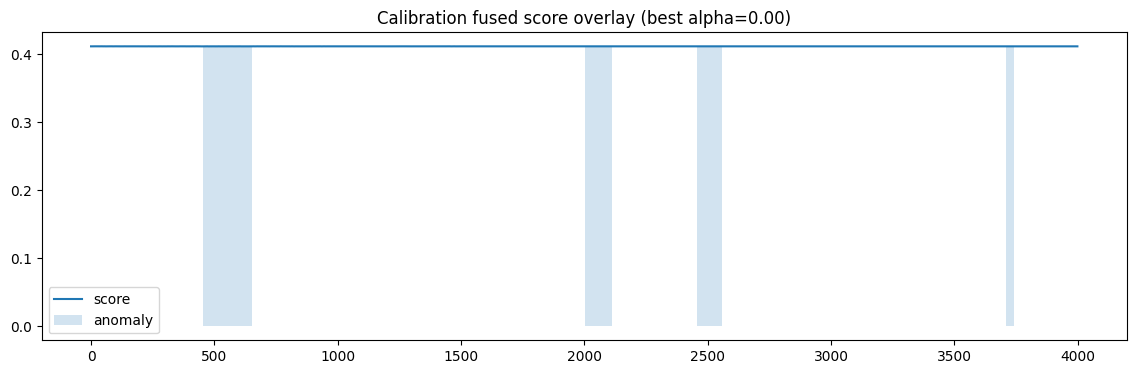

(2026-04-23 12:59:49,659) [INFO]: Register evaluations
INFO:logger:Register evaluations
(2026-04-23 12:59:49,661) [INFO]: Perform evaluations. Method[Attn_FastKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
INFO:logger:Perform evaluations. Method[Attn_FastKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
(2026-04-23 12:59:49,664) [INFO]:     [Load Data (All)] DataSets: MSL_HybridHoldout 
INFO:logger:    [Load Data (All)] DataSets: MSL_HybridHoldout 
(2026-04-23 12:59:49,690) [INFO]:     [Attn_FastKANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
INFO:logger:    [Attn_FastKANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
(2026-04-23 12:59:49,691) [INFO]:         [MSL_HybridHoldout] Using default margins (0, 5)
INFO:logger:        [MSL_HybridHoldout] Using default margins (0, 5)


In [10]:
# Cell 10 — Run the EasyTSAD experiment on the holdout dataset

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="MTS",
    dirname="/content/KAN-AD/datasets",
    datasets=[CUSTOM_DATASET],
)

# ✅ MUST MATCH CLASS NAME EXACTLY
METHOD_NAME = "Attn_FastKANAD_SVDD_AlphaTuned_Holdout"

TRAINING_SCHEMA = "naive"

gctrl.run_exps(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
    cfg_path=CFG_PATH,   # ✅ use variable instead of hardcoding
)

gctrl.set_evals([
    PointF1PA(),
    EventF1PA(mode="squeeze"),
    PointKthF1PA(k=5),
    PointAuprcPA(),
])

gctrl.do_evals(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
)

In [11]:

# Cell 11 — Load and display EasyTSAD evaluation results

BASE_EVAL = "/content/KAN-AD/Results/Evals"
if not os.path.exists(BASE_EVAL):
    BASE_EVAL = "/content/KAN-AD/KAN-AD/Results/Evals"

avg_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "avg.json"), recursive=True)
all_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "all.json"), recursive=True)

print("Found avg.json:", avg_files)
print("Found all.json:", all_files)

assert avg_files, "avg.json not found"
assert all_files, "all.json not found"

avg_path = avg_files[0]
all_path = all_files[0]

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores = json.load(f)

print("\n=== AVERAGE RESULTS (holdout final test) ===")
for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-SERIES RESULTS ===")
print("Number of series:", len(all_scores))
if len(all_scores) > 0:
    print("Example entry:", list(all_scores.items())[0])

Found avg.json: ['/content/KAN-AD/Results/Evals/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/avg.json']
Found all.json: ['/content/KAN-AD/Results/Evals/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/all.json']

=== AVERAGE RESULTS (holdout final test) ===
best f1 under pa: {'f1': 0.8476863753213362, 'precision': 0.8017018690168667, 'recall': 0.8992670870973241, 'threshold': 0.003631025552749634}
event-based f1 under pa with mode squeeze: {'f1': 0.2352941176470585, 'precision': 0.5714285714285714, 'recall': 0.14814814814814814, 'threshold': 0.00567212700843811}
best f1 under 5-delay pa: {'f1': 0.2957832242350429, 'precision': 0.26722596616696465, 'recall': 0.33117436509289244, 'threshold': 0.0035649240016937256}
point-based auprc pa: 0.8533246361861729

=== PER-SERIES RESULTS ===
Number of series: 1
Example entry: ('AllInOne', {'best f1 under pa': {'f1': 0.8476863753213362, 'precision': 0.8017018690168667, 'recall': 0.8992670870973241, 'threshold': 0.00

In [12]:

# Cell 12 — Optional: inspect runtime stats and selected alpha

BASE_RUNTIME = "/content/KAN-AD/Results/RunTime"
if not os.path.exists(BASE_RUNTIME):
    BASE_RUNTIME = "/content/KAN-AD/KAN-AD/Results/RunTime"

runtime_files = glob.glob(
    os.path.join(BASE_RUNTIME, "**", METHOD_NAME, TRAINING_SCHEMA, CUSTOM_DATASET, "*.json"),
    recursive=True
)
print("Runtime files:", runtime_files[:5])

for fp in runtime_files[:5]:
    print("\n---", fp, "---")
    try:
        print(json.dumps(json.load(open(fp, "r")), indent=2)[:3000])
    except Exception as e:
        print("Could not read:", e)

Runtime files: ['/content/KAN-AD/Results/RunTime/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json']

--- /content/KAN-AD/Results/RunTime/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json ---
{
  "train_and_valid": 2213.419671646,
  "test": 8.006071884999983
}


In [13]:
# Cell 13 — Save a compact summary for thesis/report comparison

summary_row = {
    "model": METHOD_NAME,
    "dataset": CUSTOM_DATASET,
    "original_dataset": "MSL",  # ✅ FIXED
    "training_schema": TRAINING_SCHEMA,
    "config_path": CFG_PATH,
    "window": 96,
    "order": 2,
    "lambda_svdd": 0.1,
    "emb_dim": 64,
    "calibration_dir": CALIB_DIR,
    "final_test_dir": custom_curve_dir,
}

# Add evaluation metrics
for k, v in avg.items():
    summary_row[k] = v

# Save with unique name
summary_path = f"/content/{METHOD_NAME}_{CUSTOM_DATASET}_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary_row, f, indent=2)

print("Saved summary to:", summary_path)

print("\nSummary row:")
for k, v in summary_row.items():
    print(f"{k}: {v}")

Saved summary to: /content/Attn_FastKANAD_SVDD_AlphaTuned_Holdout_MSL_HybridHoldout_summary.json

Summary row:
model: Attn_FastKANAD_SVDD_AlphaTuned_Holdout
dataset: MSL_HybridHoldout
original_dataset: MSL
training_schema: naive
config_path: /content/KAN-AD/kanad/config_attn_fastkanad_svdd_alpha_holdout.toml
window: 96
order: 2
lambda_svdd: 0.1
emb_dim: 64
calibration_dir: /content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration
final_test_dir: /content/KAN-AD/datasets/MTS/MSL_HybridHoldout/AllInOne
best f1 under pa: {'f1': 0.8476863753213362, 'precision': 0.8017018690168667, 'recall': 0.8992670870973241, 'threshold': 0.003631025552749634}
event-based f1 under pa with mode squeeze: {'f1': 0.2352941176470585, 'precision': 0.5714285714285714, 'recall': 0.14814814814814814, 'threshold': 0.00567212700843811}
best f1 under 5-delay pa: {'f1': 0.2957832242350429, 'precision': 0.26722596616696465, 'recall': 0.33117436509289244, 'threshold': 0.0035649240016937256}
point-based auprc pa: 0.853